In [2]:
import sys
sys.path.append("..")  # Adds the parent directory to the path
from utilities.correlations import *
from utilities.explanation import *
from utilities.for_ploting import *
from utilities.imputation import *
from utilities.modelling import *
from utilities.preprocessing import *
from utilities.cleaning import *
import pandas as pd

In [4]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
synthe_test = np.load('synthetic_samples_indexes.npy')


In [3]:
display_basic_info(train_df)


 Number of Rows and Columns:
 (200000, 202)

Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB

Number of Unique Values:
 ID_code    200000
target          2
var_0       94672
var_1      108932
var_2       86555
            ...  
var_195     57870
var_196    125560
var_197     40537
var_198     94153
var_199    149430
Length: 202, dtype: int64

Missing Values:
 ID_code    0
target     0
var_0      0
var_1      0
var_2      0
          ..
var_195    0
var_196    0
var_197    0
var_198    0
var_199    0
Length: 202, dtype: int64

First 5 Rows:
    ID_code  target    var_0   var_1    var_2   var_3    var_4   var_5   var_6  \
0  train_0       0   8.9255 -6.7863  11.9081  5.0930  11.4607 -9.2834  5.1187   
1  train_1       0  11.5006 -4.1473  13.8588  5.3890  12.3622  7.0433  5.6208   
2  train_2       0   8.6093 -2.7457  12.0805  7.8928  10.582

In [18]:
synthe_test = np.load('synthetic_samples_indexes.npy')
real_test = list(set(train_df.index.tolist()) - set(synthe_test))
real_test.sort()

real_test_df = test_df.loc[real_test,:]
real_test_df['target'] = np.zeros(real_test_df.shape[0])

In [19]:
from tqdm import tqdm

def count_encoding(all_samples,features):
    features_count = np.zeros((len(features), all_samples.shape[0]))

    for i,var in enumerate(tqdm(features)):
        int_var = (all_samples[var].values * 10000).round().astype(int)
        lo = int_var.min()
        int_var -= lo
        hi = int_var.max()+1
        counts_all = np.bincount(int_var, minlength=hi).astype(float)
        features_count[i,:] = counts_all[int_var]
        
    features_count_names = [var+'_count' for var in features]
    features_count = features_count.transpose()

    all_samples_count = pd.DataFrame(columns=features_count_names, data = features_count)
    all_samples_count.index = all_samples.index
    merged_df = pd.concat([all_samples,all_samples_count], axis=1)
    
    return merged_df, features_count

all_samples = pd.concat([train_df,real_test_df],axis=0)
features = [c for c in all_samples.columns if c not in ['ID_code', 'target']]
all_samples, features_count = count_encoding(all_samples,features)

100%|██████████| 200/200 [00:01<00:00, 105.45it/s]


In [20]:
print(all_samples.shape)

(300000, 402)


In [29]:
train_x = all_samples.iloc[:train_df.shape[0],:].drop(columns=["target","ID_code"])
test_x = all_samples.iloc[train_df.shape[0]:,:].drop(columns=["target","ID_code"])
train_y = all_samples.iloc[:train_df.shape[0],:]["target"]


In [27]:
params = {
    'n_estimators':500,
    'learning_rate':0.1
}

Class unbalanced: True
[LightGBM] [Info] Number of positive: 18088, number of negative: 161912
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.000002
[LightGBM] [Debug] init for col-wise cost 0.000257 seconds, init for row-wise cost 0.190454 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.255997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 55187
[LightGBM] [Info] Number of data points in the train set: 180000, number of used features: 400
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100489 -> initscore=-2.191804
[LightGBM] [Info] Start training from score -2.191804
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 16
[1]	valid_0's auc: 0.661553	valid_0's binary_logloss: 0.326764
Training until validation scores don't improve for 100 rounds
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[2]	valid_0's auc: 0.697264	valid_0's binary_

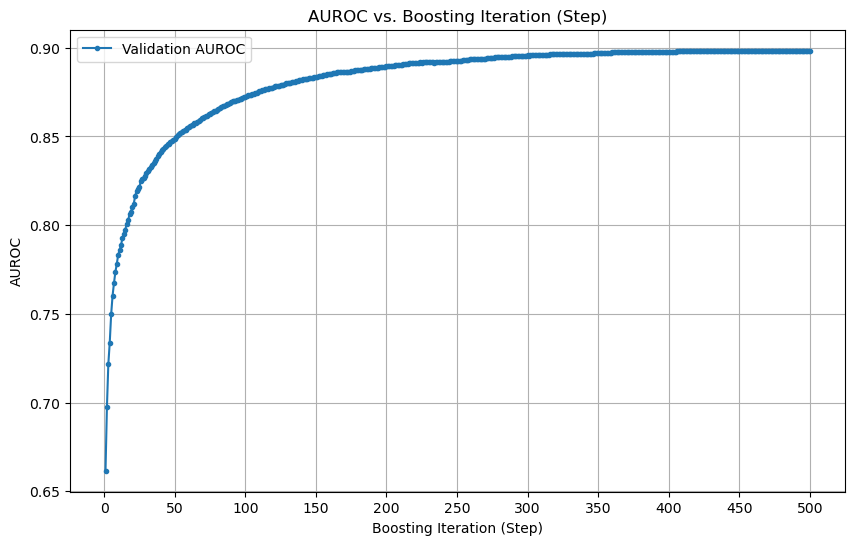


Best Iteration (based on validation AUROC): 500
Best Validation AUROC: 0.8983


In [30]:
model = training_binary_classification_with_lgbm(train_x,train_y,params=params,split=0.1)

In [31]:
predictions = model.predict_proba(test_x)[:, 1]
all_pred = np.zeros(len(test_df))
all_pred[real_test] = predictions
submission_df = pd.DataFrame({"ID_code": test_df["ID_code"], "target": all_pred})
submission_df.to_csv("submission.csv", index=False)


# Private Score: 0.90032 Public Score: 0.90345